# Analisi Classificazione tramite Regex

Questo notebook implementa una classificazione binaria *AI* / *NON AI* utilizzando un'espressione regolare mirata. L'elaborazione avviene su **10 thread simultanei** e processa i file CSV in modalità **lazy (a chunk)** per garantire un occupazione di memoria quasi nulla (Zero Memory Footprint).

Alla fine viene generata una **matrice di confusione** aggregando i risultati distribuiti per confrontare la predizione della Regex contro la colonna `CLASSIFICAZIONE` pre-calcolata.

In [16]:
import pandas as pd
import numpy as np
import re
import glob
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Setup & Regex

In [17]:
# Configurazione percorsi e thread
DATA_DIR = '../data'
FILE_PATTERN = 'classified_multiclass_aiuti_*.csv'
MAX_WORKERS = 10
CHUNK_SIZE = 100000

# Regex per rilevare AI (minimizzando i falsi positivi)
# Usiamo (?i:...) per rendere l'elenco principale case-insensitive, pur mantenendo AI e IA strettamente case-sensitive per non prendere le preposizioni.
AI_REGEX_PATTERN = r'(?i:\b(apprendimento automatico|intelligenza artificiale|robotica collaborative|visione artificiale|algoritmi predittivi|manutenzione preventiva|big data|intelligenza artificiale|machine learning|deep learning|reti neurali|computer vision|ai generativa|elaborazione del linguaggio naturale|nlp|llm|virtual assistant|virtual assistants|realtà virtuale| realtà aumentata|virtual reality|augmented reality|augmented reality|guida autonoma|drone|chatbot|classificazione semantica)\b)|\b(AI|IA)\b'
ai_regex = re.compile(AI_REGEX_PATTERN)

## 2. Funzione di Processing (Lazy)

In [ ]:
def process_file(filepath):
    print(f"Elaborazione avviata: {os.path.basename(filepath)}")
    
    # Inizializza contatori (True Positive, False Positive, True Negative, False Negative)
    # Assumiamo AI = Positive Class
    tp, fp, tn, fn = 0, 0, 0, 0
    top_fn_records = pd.DataFrame()
    top_fp_records = pd.DataFrame()
    
    try:
        # Lettura Lazy Chunked. Vengono estratte unicamente le colonne necessarie al processing.
        chunk_iter = pd.read_csv(
            filepath, 
            chunksize=CHUNK_SIZE, 
            usecols=['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'],
            dtype=str
        )
        
        for chunk in chunk_iter:
            # Sanitizzazione e parsing stringhe base
            desc = chunk['DESCRIZIONE_PROGETTO'].fillna('')
            current_classification = chunk['CLASSIFICAZIONE'].fillna('NON_AI').str.upper()
            chunk['CLASSIFICAZIONE_CONFIDENZA'] = pd.to_numeric(chunk['CLASSIFICAZIONE_CONFIDENZA'], errors='coerce').fillna(0.0)
            
            # Predizione Regex: True se troviamo il pattern, False altrimenti
            regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
            
            # Ground Truth (dal file CSV)
            true_labels = (current_classification == 'AI')
            
            # Update metriche
            tp += ((regex_preds == True) & (true_labels == True)).sum()
            fp += ((regex_preds == True) & (true_labels == False)).sum()
            tn += ((regex_preds == False) & (true_labels == False)).sum()
            fn += ((regex_preds == False) & (true_labels == True)).sum()
            
            # Estrazione False Negatives
            fn_mask = (regex_preds == False) & (true_labels == True)
            if fn_mask.any():
                fn_chunk = chunk[fn_mask]
                top_fn_records = pd.concat([top_fn_records, fn_chunk])
                # Mantieni solo i top 50 in memoria per file per ottimizzare
                top_fn_records = top_fn_records.sort_values(by='CLASSIFICAZIONE_CONFIDENZA', ascending=False).head(50)
                
            # Estrazione False Positives
            fp_mask = (regex_preds == True) & (true_labels == False)
            if fp_mask.any():
                fp_chunk = chunk[fp_mask]
                top_fp_records = pd.concat([top_fp_records, fp_chunk])
                # Mantieni solo i top 50 in memoria per file per ottimizzare
                top_fp_records = top_fp_records.sort_values(by='CLASSIFICAZIONE_CONFIDENZA', ascending=False).head(50)
            
    except Exception as e:
        print(f"Errore in {filepath}: {e}")
        return None
        
    print(f"Completato: {os.path.basename(filepath)} | TP:{tp} FP:{fp} TN:{tn} FN:{fn}")
    return {
        'file': os.path.basename(filepath),
        'tp': tp,        'fp': fp,
        'tn': tn,        'fn': fn,
        'top_fns': top_fn_records,
        'top_fps': top_fp_records
    }

## 3. Multithreading Execution

In [19]:
files = glob.glob(os.path.join(DATA_DIR, FILE_PATTERN))
print(f"\nTrovati {len(files)} file per il processing concorrente su 10 thread.")

results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Assegna i task ai worker nel thread pool
    futures = {executor.submit(process_file, f): f for f in files}
    
    for future in as_completed(futures):
        res = future.result()
        if res:
            results.append(res)

print("\nTutti i thread sono stati completati con successo.")


Trovati 12 file per il processing concorrente su 10 thread.
Elaborazione avviata: classified_multiclass_aiuti_2016.csv
Elaborazione avviata: classified_multiclass_aiuti_2017.csv
Elaborazione avviata: classified_multiclass_aiuti_2015.csv
Elaborazione avviata: classified_multiclass_aiuti_2014.csv
Elaborazione avviata: classified_multiclass_aiuti_2025.csv
Elaborazione avviata: classified_multiclass_aiuti_2019.csv
Elaborazione avviata: classified_multiclass_aiuti_2018.csv
Elaborazione avviata: classified_multiclass_aiuti_2024.csv
Elaborazione avviata: classified_multiclass_aiuti_2023.csv
Elaborazione avviata: classified_multiclass_aiuti_2022.csv
Completato: classified_multiclass_aiuti_2015.csv | TP:0 FP:1 TN:2297 FN:1
Elaborazione avviata: classified_multiclass_aiuti_2020.csv
Completato: classified_multiclass_aiuti_2016.csv | TP:12 FP:4 TN:8360 FN:2
Elaborazione avviata: classified_multiclass_aiuti_2021.csv
Completato: classified_multiclass_aiuti_2014.csv | TP:0 FP:0 TN:15448 FN:0


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2017.csv | TP:39 FP:390 TN:214050 FN:67


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2019.csv | TP:312 FP:681 TN:512931 FN:341


...

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expre

Completato: classified_multiclass_aiuti_2023.csv | TP:489 FP:8095 TN:6469583 FN:544


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)


Completato: classified_multiclass_aiuti_2024.csv | TP:2438 FP:7025 TN:6012242 FN:579

Tutti i thread sono stati completati con successo.


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)
/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_28940/1493565615.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  regex_preds = desc.str.contains(ai_regex, regex=True).fillna(False)


## 4. Aggregazione e Matrice di Confusione

--- Risultati Totali Aggregati ---
Totale Record: 23,957,368
True Positives (TP): 8,603
False Positives (FP): 59,879
True Negatives (TN): 23,883,650
False Negatives (FN): 5,236



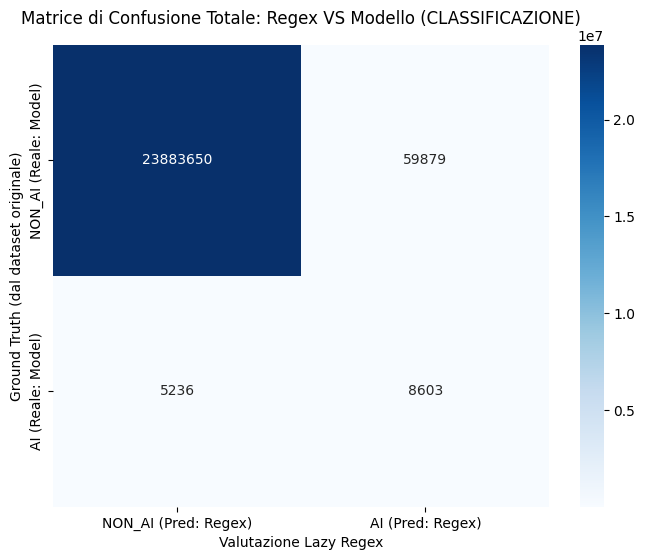

In [20]:
if not results:
    print("Nessun risultato disponibile da processare.")
else:
    # Aggregazione
    total_tp = sum(r['tp'] for r in results)
    total_fp = sum(r['fp'] for r in results)
    total_tn = sum(r['tn'] for r in results)
    total_fn = sum(r['fn'] for r in results)

    print("--- Risultati Totali Aggregati ---")
    print(f"Totale Record: {total_tp + total_fp + total_tn + total_fn:,}")
    print(f"True Positives (TP): {total_tp:,}")
    print(f"False Positives (FP): {total_fp:,}")
    print(f"True Negatives (TN): {total_tn:,}")
    print(f"False Negatives (FN): {total_fn:,}\n")
    
    # Matrice di Confusione
    conf_matrix = np.array([
        [total_tn, total_fp], 
        [total_fn, total_tp]
    ])
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=['NON_AI (Pred: Regex)', 'AI (Pred: Regex)'], 
        yticklabels=['NON_AI (Reale: Model)', 'AI (Reale: Model)']
    )
    
    plt.title('Matrice di Confusione Totale: Regex VS Modello (CLASSIFICAZIONE)', pad=15)
    plt.ylabel('Ground Truth (dal dataset originale)')
    plt.xlabel('Valutazione Lazy Regex')
    plt.show()

## 5. Analisi False Negatives ad Alta Confidenza

Analizziamo i progetti che il modello ha classificato come "AI" con un'elevata **CLASSIFICAZIONE_CONFIDENZA**, ma che la regex non è riuscita a catturare (Classificati preventivamente dalla regex come "NON_AI").

In [21]:
if results:
    # Aggrega tutti i dataframe dei false negatives trovati in ogni file
    all_fns = pd.concat([r['top_fns'] for r in results if 'top_fns' in r and not r['top_fns'].empty])
    
    if not all_fns.empty:
        # Ordina per confidenza discendente e prendi i top 20
        top_fns_overall = all_fns.sort_values(by='CLASSIFICAZIONE_CONFIDENZA', ascending=False).head(20)
        
        print("I 20 progetti classificati 'AI' dal modello (con highest CONFIDENZA) ma mancati dalla regex:\n")
        
        for idx, row in top_fns_overall.iterrows():
            print(f"Confidenza: {row['CLASSIFICAZIONE_CONFIDENZA']:.4f}")
            desc = row['DESCRIZIONE_PROGETTO']
            # Limitiamo a 500 caratteri per leggibilità
            if len(desc) > 500:
                desc = desc[:497] + "..."
            print(f"Descrizione: {desc}")
            print("-" * 80)
    else:
        print("Nessun false negative trovato.")
else:
    print("Elaborazione non completata, risultati assenti.")

I 20 progetti classificati 'AI' dal modello (con highest CONFIDENZA) ma mancati dalla regex:

Confidenza: 0.9985
Descrizione: Il progetto SFIDA (Smart Frail Individual Data Analysis) vuole creare un Living Lab popolato da imprese, centri di Ricerca e strutture sanitarie/sportive con due finalità:
a) utilizzare wearable certificati per raccogliere dati qualitativamente validi per l?addestramento di sistemi complessi mediante strumenti di A.I
b) validare soluzioni a supporto del cittadino, anche in situazioni di fragilità, abbinando wearable e serious game per migliorare la compliance grazie al coinvolgimento attivo.
--------------------------------------------------------------------------------
Confidenza: 0.9985
Descrizione: Il progetto Neurocheck prevede l¿acquisto di un software e dell¿hardware correlato, necessario per l¿acquisizione ed elaborazione di immagini per l¿ispezione visiva artificiale.  Questo sistema consente di sfruttare fino a due processi di acquisizione contemporane

## 6. Analisi False Positives ad Alta Confidenza

Analizziamo i progetti che il modello ha classificato come "NON_AI" con un'elevata **CLASSIFICAZIONE_CONFIDENZA** (> 0.9), ma che la regex ha classificato come "AI" (Falsi Positivi).

In [ ]:
if results:
    # Aggrega tutti i dataframe dei false positives trovati in ogni file
    all_fps = pd.concat([r['top_fps'] for r in results if 'top_fps' in r and not r['top_fps'].empty])
    
    if not all_fps.empty:
        # Filtra per confidenza > 0.9 e prendi i top 20
        high_conf_fps = all_fps[all_fps['CLASSIFICAZIONE_CONFIDENZA'] > 0.9]
        
        if high_conf_fps.empty:
            print("Nessun false positive con confidenza > 0.9 trovato.")
        else:
            top_fps_overall = high_conf_fps.sort_values(by='CLASSIFICAZIONE_CONFIDENZA', ascending=False).head(20)
            print("I progetti classificati 'NON_AI' dal modello (con highest CONFIDENZA > 0.9) che la regex ha classificato 'AI':\n")
            
            for idx, row in top_fps_overall.iterrows():
                print(f"Confidenza: {row['CLASSIFICAZIONE_CONFIDENZA']:.4f}")
                desc = row['DESCRIZIONE_PROGETTO']
                # Limitiamo a 500 caratteri per leggibilità
                if pd.notna(desc) and len(desc) > 500:
                    desc = desc[:497] + "..."
                print(f"Descrizione: {desc}")
                print("-" * 80)
    else:
        print("Nessun false positive trovato.")
else:
    print("Elaborazione non completata, risultati assenti.")